<a href="https://colab.research.google.com/github/anshyy12/Machine_Learning/blob/main/house%20price%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
df = pd.read_csv('/content/housing.csv')

In [147]:
df.shape

(20640, 10)

In [148]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [150]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [151]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [152]:
df.duplicated().sum()

np.int64(0)

In [153]:
df.dropna(inplace=True)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [185]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [156]:
x = df.drop(['median_house_value'],axis=1)
y = df['median_house_value']

In [157]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [158]:
train_data =x_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
17727,-121.80,37.32,14.0,4412.0,924.0,2698.0,891.0,4.7027,<1H OCEAN,227600.0
2057,-119.63,36.64,33.0,1036.0,181.0,620.0,174.0,3.4107,INLAND,110400.0
6453,-118.06,34.12,25.0,3891.0,848.0,1848.0,759.0,3.6639,INLAND,248100.0
4619,-118.31,34.07,28.0,2362.0,949.0,2759.0,894.0,2.2364,<1H OCEAN,305600.0
15266,-117.27,33.04,27.0,1839.0,392.0,1302.0,404.0,3.5500,NEAR OCEAN,214600.0
...,...,...,...,...,...,...,...,...,...,...
11397,-117.97,33.72,24.0,2991.0,500.0,1437.0,453.0,5.4286,<1H OCEAN,273400.0
12081,-117.54,33.76,5.0,5846.0,1035.0,3258.0,1001.0,4.7965,<1H OCEAN,160800.0
5447,-118.42,34.01,42.0,1594.0,369.0,952.0,362.0,3.0990,<1H OCEAN,335400.0
866,-122.04,37.57,12.0,5719.0,1064.0,3436.0,1057.0,5.2879,NEAR BAY,231200.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

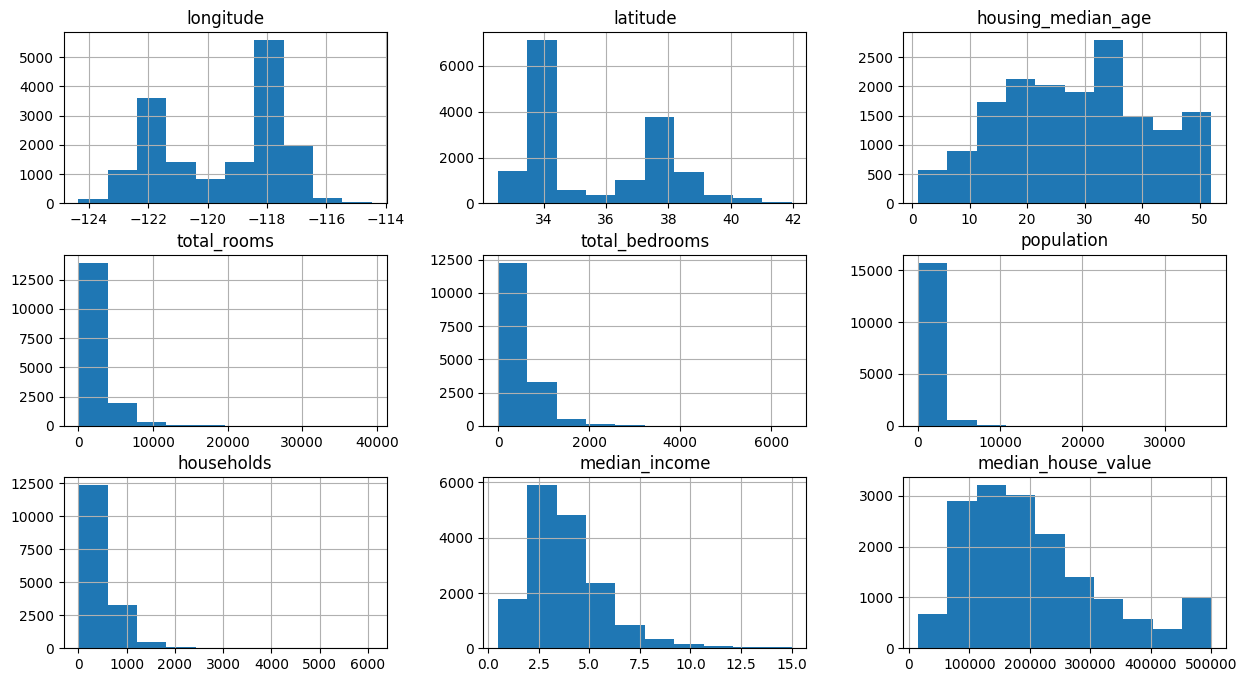

In [159]:
train_data.hist(figsize=(15,8))

<Axes: >

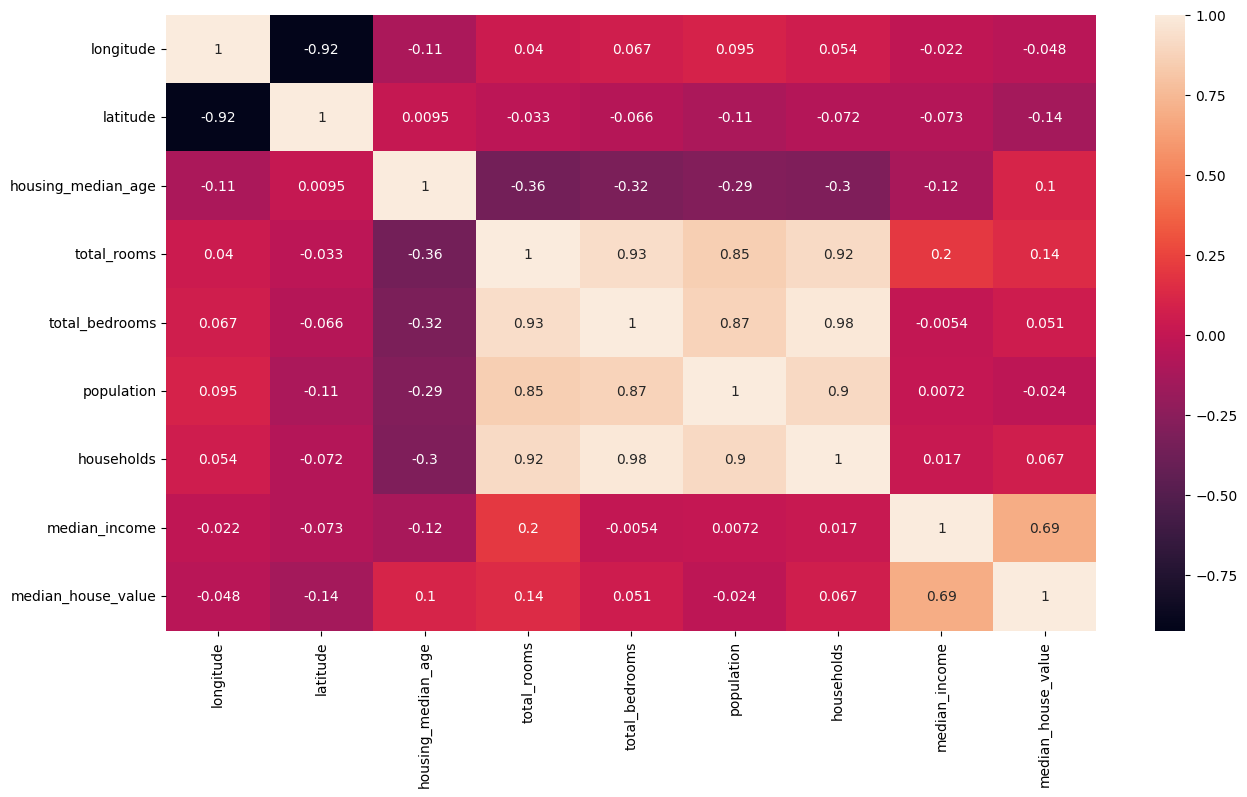

In [160]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

In [161]:
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

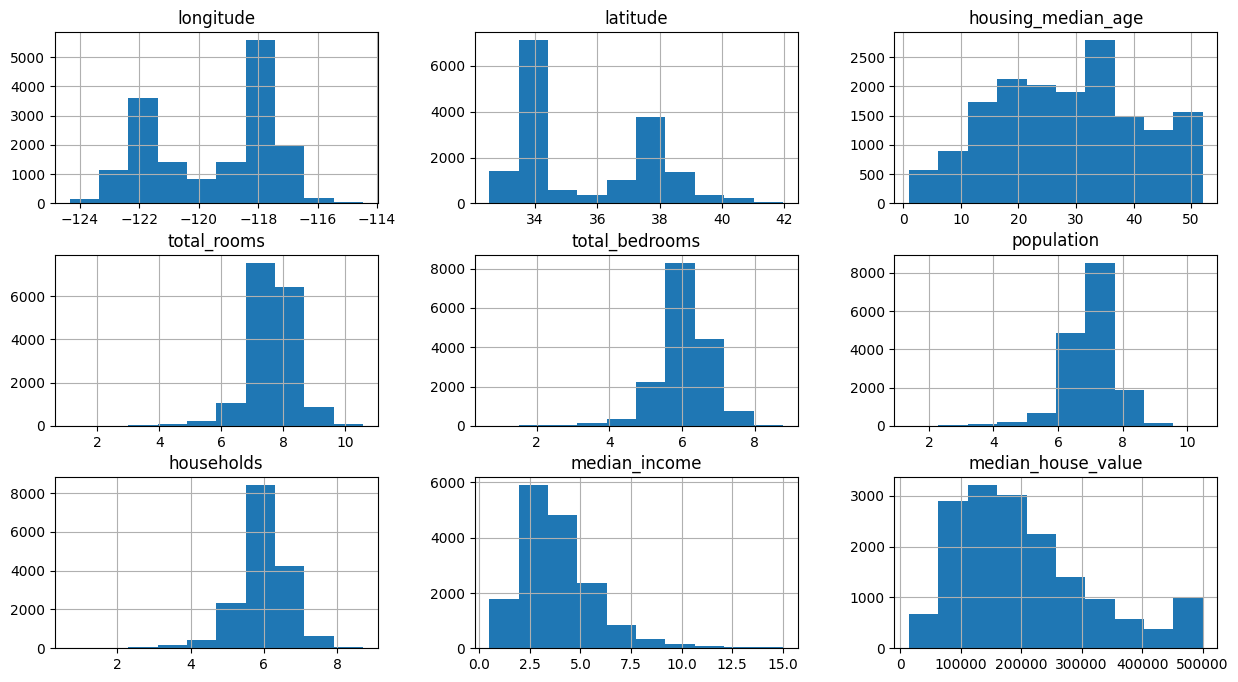

In [162]:
train_data.hist(figsize=(15,8))

In [163]:
train_data.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,7231
INLAND,5156
NEAR OCEAN,2114
NEAR BAY,1842
ISLAND,3


In [164]:
train_data=train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'],axis=1)

<Axes: >

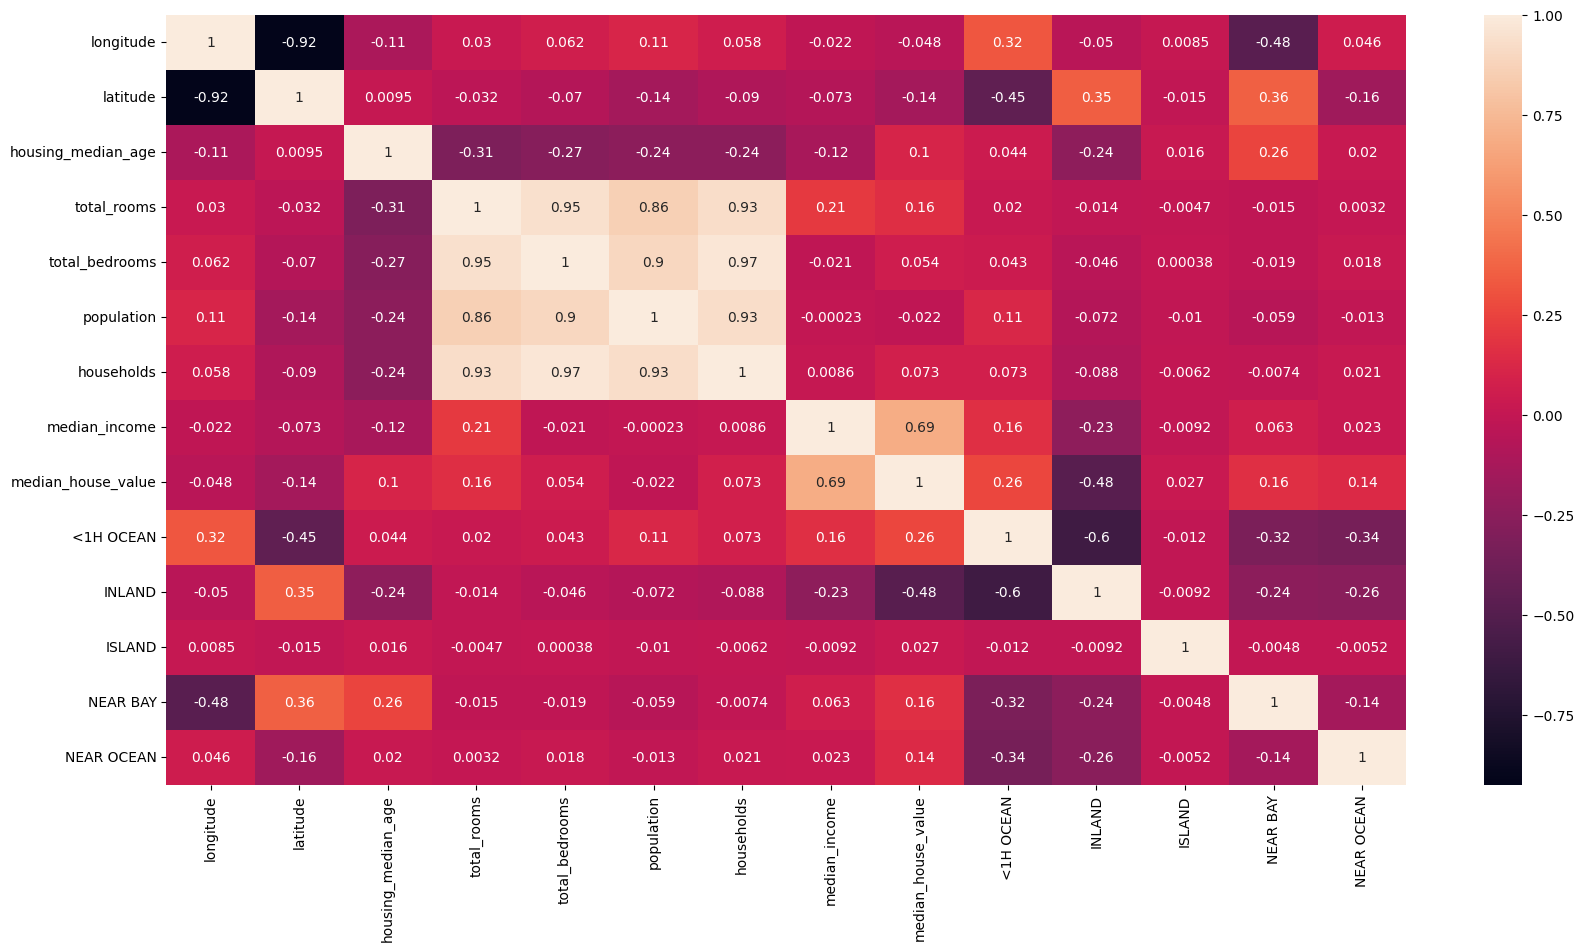

In [165]:
plt.figure(figsize=(20,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

<Axes: xlabel='longitude', ylabel='latitude'>

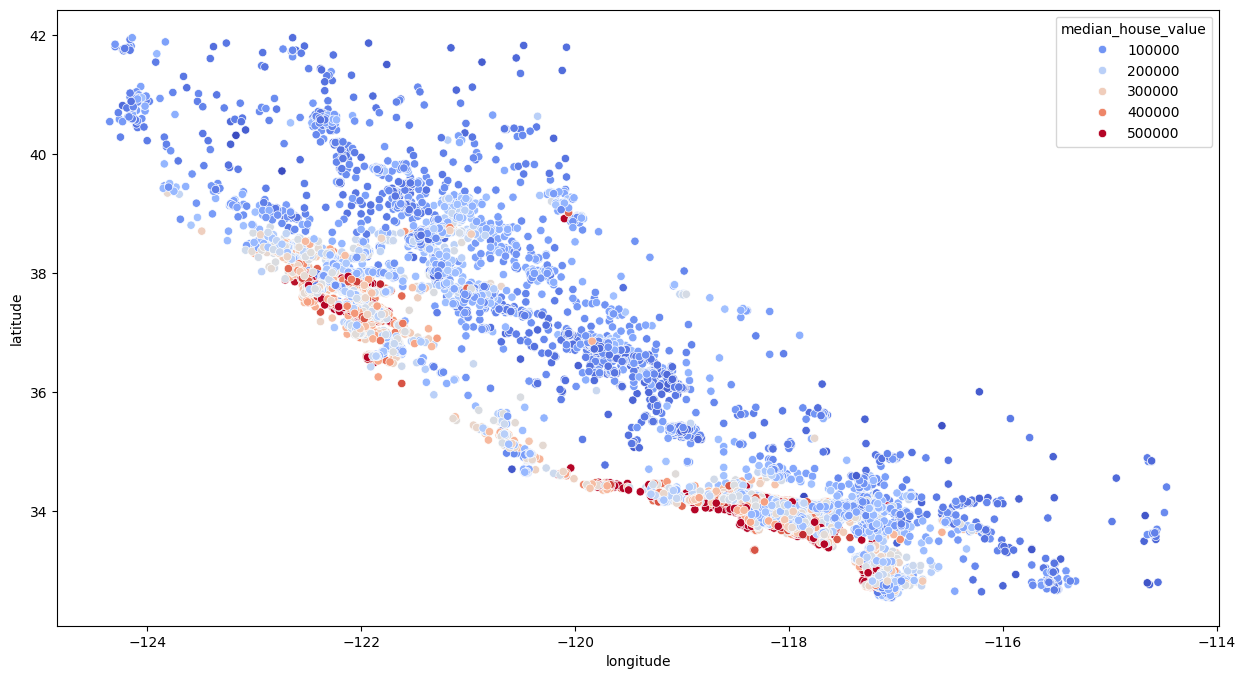

In [166]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='longitude',y='latitude',hue='median_house_value',data=train_data, palette="coolwarm")

In [167]:
train_data['bedroom_ratio'] = train_data['total_bedrooms']/train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms']/train_data['households']


<Axes: >

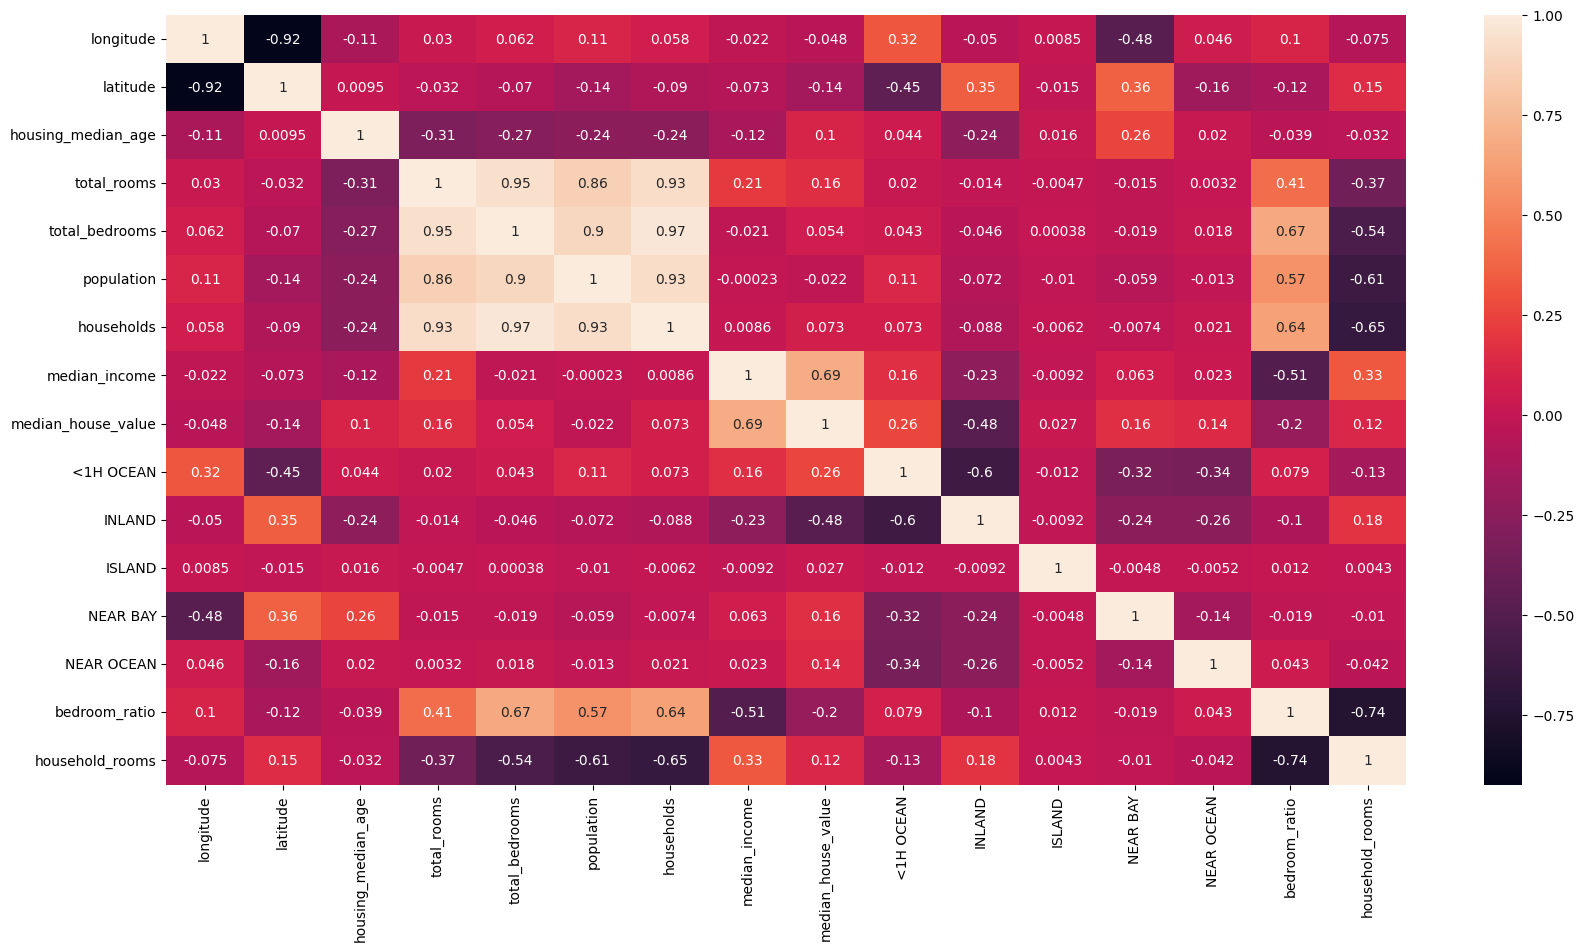

In [168]:
plt.figure(figsize=(20,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

In [169]:
scaler = StandardScaler()

In [171]:
x_train = train_data.drop(['median_house_value'],axis=1)
y_train = train_data['median_house_value']



In [172]:
reg = LinearRegression()
reg.fit(x_train_s,y_train)

LinearRegression()

In [173]:
test_data = x_test.join(y_test)


In [174]:
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms']+1)
test_data['total_rooms'] = np.log(test_data['total_rooms']+1)
test_data['population'] = np.log(test_data['population']+1)
test_data['households'] = np.log(test_data['households']+1)

In [175]:
test_data=test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(['ocean_proximity'],axis=1)
test_data['bedroom_ratio'] = test_data['total_bedrooms']/test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms']/test_data['households']


In [176]:
x_test = test_data.drop(['median_house_value'],axis=1)
y_test = test_data['median_house_value']


In [177]:
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)


In [178]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
14416,-117.24,32.79,20.0,6.869014,5.631212,6.265301,5.541264,3.1838,245800.0,False,False,False,False,True,0.819799,1.239612
16383,-121.29,38.01,2.0,8.764678,7.018402,8.110127,6.864848,4.4871,137900.0,False,True,False,False,False,0.800760,1.276748
7731,-118.14,33.92,31.0,8.224700,6.749931,7.746733,6.687109,3.2237,218200.0,True,False,False,False,False,0.820690,1.229934
1410,-122.07,37.94,30.0,7.139660,5.624018,6.562444,5.402677,2.8920,220800.0,False,False,False,True,False,0.787715,1.321504
1335,-121.89,37.99,4.0,7.683404,6.393591,6.834109,6.135565,4.1016,170500.0,False,True,False,False,False,0.832130,1.252273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8291,-118.15,33.76,36.0,7.978311,6.666957,7.076654,6.620073,3.5985,500001.0,False,False,False,False,True,0.835635,1.205170
6274,-117.95,34.03,33.0,7.486053,5.978886,7.325149,5.932245,3.3389,157900.0,True,False,False,False,False,0.798670,1.261926
2997,-119.03,35.32,12.0,7.909122,6.309918,7.166266,6.261492,2.5575,100200.0,False,True,False,False,False,0.797803,1.263137
13440,-117.42,34.08,28.0,7.741099,6.040255,7.180070,6.098074,3.4844,127700.0,False,True,False,False,False,0.780284,1.269433


In [195]:
from sklearn.ensemble import RandomForestRegressor

In [196]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train_s, y_train)

RandomForestRegressor(random_state=42)

In [198]:
rf_pred = rf_model.predict(x_test_s)

In [181]:
y_pred = reg.predict(x_test_s)

In [199]:
print("--- Random Forest Metrics ---")
print(f"R² Score: {r2_score(y_test, rf_pred):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, rf_pred):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, rf_pred)):,.2f}")

--- Random Forest Metrics ---
R² Score: 0.8194
MAE: $32,559.57
RMSE: $49,690.99


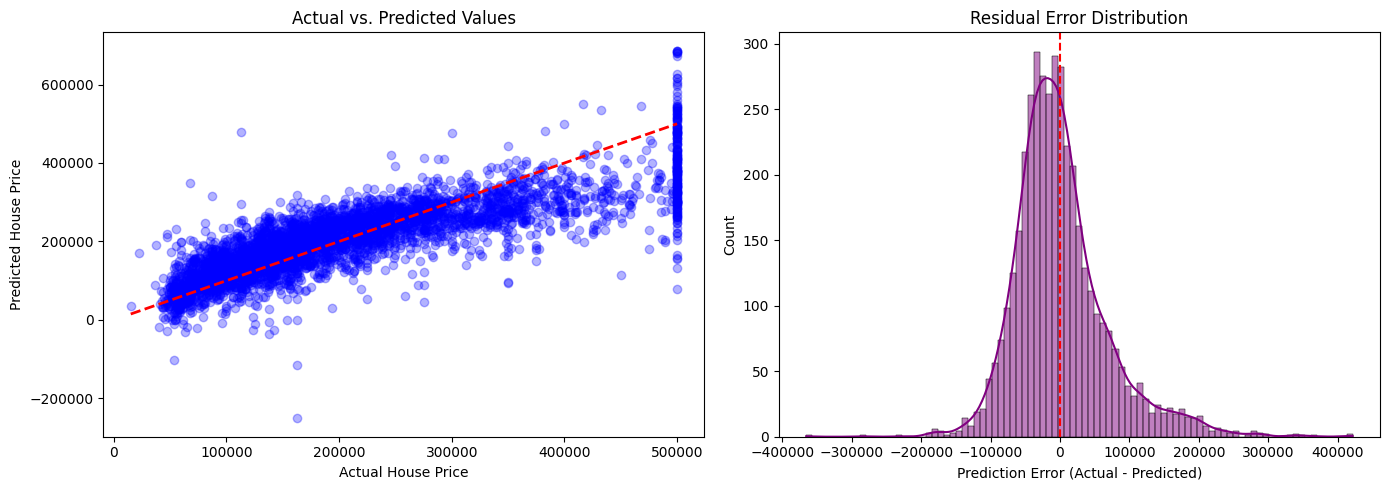

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred, alpha=0.3, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual House Price")
axes[0].set_ylabel("Predicted House Price")
axes[0].set_title("Actual vs. Predicted Values")


residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Prediction Error (Actual - Predicted)")
axes[1].set_title("Residual Error Distribution")

plt.tight_layout()
plt.show()

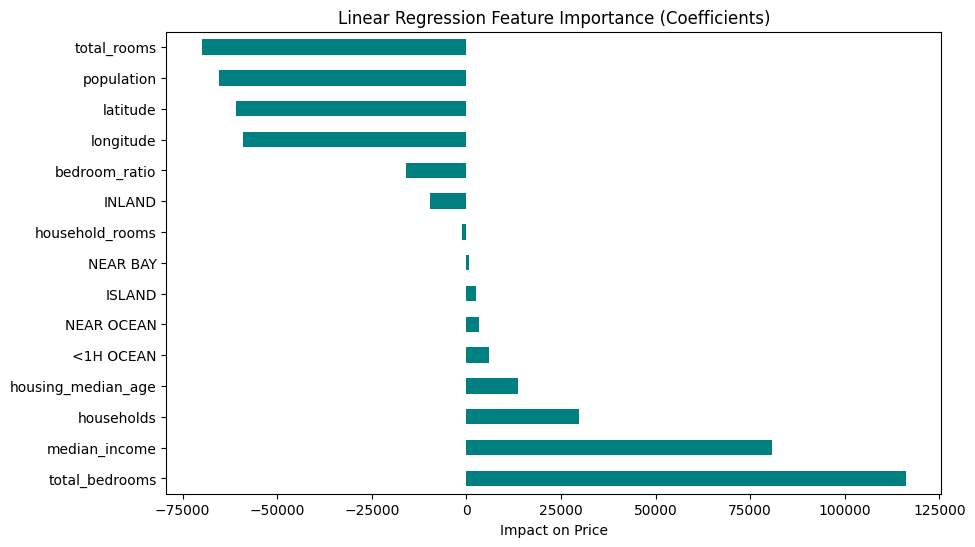

In [201]:
coefficients = pd.Series(reg.coef_, index=x_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
coefficients.plot(kind='barh', color='teal')
plt.title("Linear Regression Feature Importance (Coefficients)")
plt.xlabel("Impact on Price")
plt.show()

In [202]:
new_house = pd.DataFrame([{
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41.0,
    'total_rooms': 880.0,
    'total_bedrooms': 129.0,
    'population': 322.0,
    'households': 126.0,
    'median_income': 8.3252,
    'ocean_proximity': 'NEAR BAY'
}])

In [203]:
new_house['total_bedrooms'] = np.log(new_house['total_bedrooms'] + 1)
new_house['total_rooms']    = np.log(new_house['total_rooms'] + 1)
new_house['population']     = np.log(new_house['population'] + 1)
new_house['households']     = np.log(new_house['households'] + 1)


categories = ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']
for cat in categories:
    new_house[cat] = (new_house['ocean_proximity'] == cat)

new_house.drop(['ocean_proximity'], axis=1, inplace=True)

In [204]:
new_house['bedroom_ratio']   = new_house['total_bedrooms'] / new_house['total_rooms']
new_house['household_rooms'] = new_house['total_rooms'] / new_house['households']

In [205]:
new_house = new_house[x_train.columns]

In [206]:
new_house_scaled = scaler.transform(new_house)

In [207]:
predicted_price = reg.predict(new_house_scaled)

In [208]:
print(f"Predicted House Value: ${predicted_price[0]:,.2f}")

Predicted House Value: $409,898.60
